In [145]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [146]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [147]:
df = pd.read_csv('/content/drive/MyDrive/AI/DL/RNN/monthly_milk_production.csv',index_col='Date',parse_dates=True)
df.head()

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


In [148]:
df.tail()

,Production
Date,
1975-08-01,858
1975-09-01,817
1975-10-01,827
1975-11-01,797
1975-12-01,843


In [149]:
df.describe()

,Production
count,168.000000
mean,754.708333
std,102.204524
min,553.000000
25%,677.750000
50%,761.000000
75%,824.500000
max,969.000000


In [150]:
df.isna().sum()

,0
Production,0


In [151]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 168 entries, 1962-01-01 to 1975-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Production  168 non-null    int64
dtypes: int64(1)
memory usage: 2.6 KB


<Axes: xlabel='Date'>

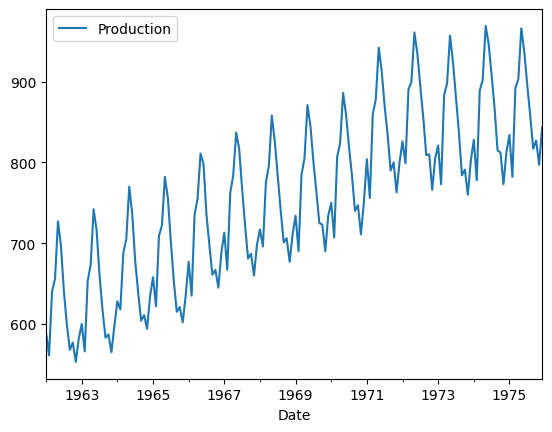

In [152]:
df.plot()

In [153]:
df.shape

(168, 1)

In [154]:
# 14 years of data are there.
# split the data into 13 training and 1 testing years. (total=168)

In [155]:
xtrain = df.iloc[:156]
xtrain.shape

(156, 1)

In [156]:
xtest = df.iloc[156:]
xtest.shape

(12, 1)

In [157]:
#In normalisation, here we use min-max scaler. Because, for a 0-1 range, min-max scaler is used.

In [158]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler()
sc.fit(xtrain)

MinMaxScaler()

In [159]:
train = sc.transform(xtrain)
train

array([[0.08653846],
       [0.01923077],
       [0.20913462],
       [0.24759615],
       [0.41826923],
       [0.34615385],
       [0.20913462],
       [0.11057692],
       [0.03605769],
       [0.05769231],
       [0.        ],
       [0.06971154],
       [0.11298077],
       [0.03125   ],
       [0.24038462],
       [0.28846154],
       [0.45432692],
       [0.39182692],
       [0.25721154],
       [0.15384615],
       [0.07211538],
       [0.08173077],
       [0.02884615],
       [0.10817308],
       [0.18028846],
       [0.15625   ],
       [0.32451923],
       [0.36538462],
       [0.52163462],
       [0.43990385],
       [0.30048077],
       [0.20673077],
       [0.12259615],
       [0.13942308],
       [0.09855769],
       [0.19471154],
       [0.25240385],
       [0.16586538],
       [0.375     ],
       [0.40625   ],
       [0.55048077],
       [0.48798077],
       [0.35817308],
       [0.24038462],
       [0.14903846],
       [0.16346154],
       [0.11778846],
       [0.197

In [160]:
test = sc.transform(xtest)
test

array([[0.67548077],
       [0.55048077],
       [0.81490385],
       [0.84134615],
       [0.99278846],
       [0.92307692],
       [0.82451923],
       [0.73317308],
       [0.63461538],
       [0.65865385],
       [0.58653846],
       [0.69711538]])

In [161]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

In [162]:
n_input = 12
n_features = 1
generator = TimeseriesGenerator(train,train,length=n_input,batch_size=1)
generator

In [163]:
generator[0]

(array([[[0.08653846],
         [0.01923077],
         [0.20913462],
         [0.24759615],
         [0.41826923],
         [0.34615385],
         [0.20913462],
         [0.11057692],
         [0.03605769],
         [0.05769231],
         [0.        ],
         [0.06971154]]]),
 array([[0.11298077]]))

In [164]:
generator[1]

(array([[[0.01923077],
         [0.20913462],
         [0.24759615],
         [0.41826923],
         [0.34615385],
         [0.20913462],
         [0.11057692],
         [0.03605769],
         [0.05769231],
         [0.        ],
         [0.06971154],
         [0.11298077]]]),
 array([[0.03125]]))

In [165]:
from keras.models import Sequential
from keras.layers import Dense,LSTM

In [166]:
model = Sequential()
model.add(LSTM(100,activation='relu',input_shape=(n_input,n_features)))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [167]:
model

<Sequential name=sequential_2, built=True>

In [168]:
model.compile(optimizer='adam',loss='mse')

In [169]:
r = model.fit(generator,epochs=50)

Epoch 1/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0527
Epoch 2/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0223
Epoch 3/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0166
Epoch 4/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0104
Epoch 5/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0063
Epoch 6/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0143
Epoch 7/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0047
Epoch 8/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0041
Epoch 9/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0044
Epoch 10/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0033
Epoch 11/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0056
Epoch 12/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0042
Epoch 13/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0032
Epoch 14/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0034
Epoch 15/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - lo

In [170]:
r.history

{'loss': [0.052704110741615295,
  0.0223027765750885,
  0.016553422436118126,
  0.010371237993240356,
  0.006260991562157869,
  0.014256628230214119,
  0.0047277300618588924,
  0.004079505801200867,
  0.004413244780153036,
  0.003330230014398694,
  0.00563456118106842,
  0.004231708124279976,
  0.0031805234029889107,
  0.0033887356985360384,
  0.0034397575072944164,
  0.0033687539398670197,
  0.003846594365313649,
  0.0033212853595614433,
  0.003971260506659746,
  0.0030857007950544357,
  0.0034198861103504896,
  0.003420989727601409,
  0.004160521551966667,
  0.0046173506416380405,
  0.0030538556165993214,
  0.004726272542029619,
  0.003361102659255266,
  0.0032608846668154,
  0.0033991928212344646,
  0.003116951324045658,
  0.00394993694499135,
  0.0033285871613770723,
  0.003095924621447921,
  0.0030245997477322817,
  0.00268761720508337,
  0.0024943044409155846,
  0.0026375099550932646,
  0.0027811499312520027,
  0.002740797121077776,
  0.0029669643845409155,
  0.002628110814839601

In [171]:
#for getting the prediction testing, the last 12 is used. For getting the second value , the last 11 + previous predicted output is taken.

In [172]:
data = train[-12:]
last_train_batch = data.reshape(1,12,1)
ypred=model.predict(last_train_batch)[0]
ypred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step


array([0.6340296], dtype=float32)

In [173]:
#testing_size should be maximum or equal to memory(ie,12).

In [174]:
test_prediction = []
last_batch = train[-n_input:]
last_batch = last_batch.reshape((1,n_input,n_features))

In [175]:
for i in range(len(test)):
  ypred = model.predict(last_batch)[0]
  test_prediction.append(ypred)
  last_batch = np.append(last_batch[:,1:,:],[[ypred]],axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


In [176]:
test_prediction

[array([0.6340296], dtype=float32),
 array([0.6523643], dtype=float32),
 array([0.8040551], dtype=float32),
 array([0.88858336], dtype=float32),
 array([0.96896774], dtype=float32),
 array([0.96550864], dtype=float32),
 array([0.9113201], dtype=float32),
 array([0.80879945], dtype=float32),
 array([0.6970752], dtype=float32),
 array([0.6374403], dtype=float32),
 array([0.5926783], dtype=float32),
 array([0.6250336], dtype=float32)]

In [177]:
prediction = sc.inverse_transform(test_prediction)
prediction

array([[816.75632477],
       [824.38355446],
       [887.4869194 ],
       [922.65067863],
       [956.09057808],
       [954.65159416],
       [932.10915756],
       [889.46056938],
       [842.98327827],
       [818.17517471],
       [799.55417633],
       [813.01398468]])

In [179]:
xtest['prediction']=prediction
xtest

/tmp/ipykernel_1082/3248557821.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  xtest['prediction']=prediction


,Production,prediction
Date,,
1975-01-01,834,816.756325
1975-02-01,782,824.383554
1975-03-01,892,887.486919
1975-04-01,903,922.650679
1975-05-01,966,956.090578
1975-06-01,937,954.651594
1975-07-01,896,932.109158
1975-08-01,858,889.460569
1975-09-01,817,842.983278


In [180]:
from sklearn.metrics import r2_score
r2_score(xtest['Production'],xtest['prediction'])

0.8050953055405183